## Exercise 1

### Problem
Sets in Python are unordered collections, meaning their elements do not have a fixed order. Therefore, accessing elements by index leads to unpredictable results.

### Fix
Convert the set into a list to ensure consistent ordering before indexing.

In [1]:
from typing import List

def id_to_fruit(fruit_id: int, fruits: List[str]) -> str:
    """
    Reason:
    Sets are unordered.

    FIX:
    Convert the set to a list because lists are ordered.
    """
    idx = 0
    for fruit in fruits:
        if fruit_id == idx:
            return fruit
        idx += 1
    raise RuntimeError(f"Fruit with id {fruit_id} does not exist")


# Test
name1 = id_to_fruit(1, ["apple", "orange", "melon", "kiwi", "strawberry"])
name3 = id_to_fruit(3, ["apple", "orange", "melon", "kiwi", "strawberry"])
name4 = id_to_fruit(4, ["apple", "orange", "melon", "kiwi", "strawberry"])

print(name1)
print(name3)
print(name4)

orange
kiwi
strawberry


## Exercise 2

### Problem
The assignment uses wrong value during the swap (coords[:, 1] instead of coords[:, 0]), leading to incorrect results.

### Fix
Creating a copy of the array before swaping to avoid overwriting.

In [2]:
import numpy as np

def swap(coords: np.ndarray):

    """
    Problem:
    Swapping x and y coords are wrong.(repeated coords[:,1])
    FIX:
    Using a copy or temp to prevent overwriting values.
    """
    
    coords_copy = coords.copy()
    coords[:, 0] = coords_copy[:, 1]
    coords[:, 1] = coords_copy[:, 0]
    coords[:, 2] = coords_copy[:, 3]
    coords[:, 3] = coords_copy[:, 2]
    
    return coords

#Test  
coords = np.array([[10, 5, 15, 6, 0],
                   [11, 3, 13, 6, 0],
                   [5, 3, 13, 6, 1],
                   [4, 4, 13, 6, 1],
                   [6, 5, 13, 16, 1]])
swapped_coords = swap(coords)
print(swapped_coords)

[[ 5 10  6 15  0]
 [ 3 11  6 13  0]
 [ 3  5  6 13  1]
 [ 4  4  6 13  1]
 [ 5  6 16 13  1]]


## Exercise 3

### Problem
The precision and recall values are plotted incorrectly. The axes are swapped, leading to a misleading visualization.

### Fix
Ensure that precision is plotted on the x-axis and recall on the y-axis.

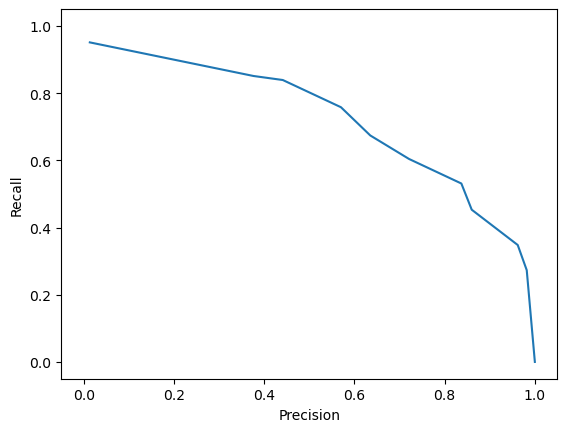

In [3]:
%matplotlib inline

import csv
import numpy as np
import matplotlib.pyplot as plt

def plot_data(csv_file_path: str):
    
    """
    Problem:
    Precision and recall values are plotted incorrectly.
    FIX:
    Correcting axis order (precision on x-axis and recall on y-axis).
    """
    
    # load data
    results=[]
    with open(csv_file_path) as result_csv:
        csv_reader = csv.reader(result_csv, delimiter=',')
        next(csv_reader)
        for row in csv_reader:
            results.append(row)
        results = np.array(results, dtype=float)
    
    # plot precision-recall curve
    plt.plot(results[:, 0], results[:, 1])
    plt.ylim([-0.05, 1.05])
    plt.xlim([-0.05, 1.05])
    plt.xlabel('Precision')
    plt.ylabel('Recall')
    plt.show()


# Test
with open("data_file.csv", "w", newline='') as f:
    w = csv.writer(f)
    w.writerow(["precision", "recall"])
    w.writerows([[0.013,0.951],
                 [0.376,0.851],
                 [0.441,0.839],
                 [0.570,0.758],
                 [0.635,0.674],
                 [0.721,0.604],
                 [0.837,0.531],
                 [0.860,0.453],
                 [0.962,0.348],
                 [0.982,0.273],
                 [1.0,0.0]])


plot_data('data_file.csv')

## Exercise 4

### Bugs Fixed
Structural bug: batch size mismatch
Cosmetic bug: incorrect loop condition

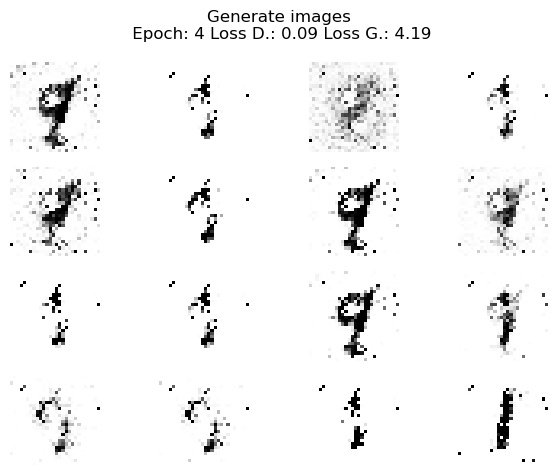

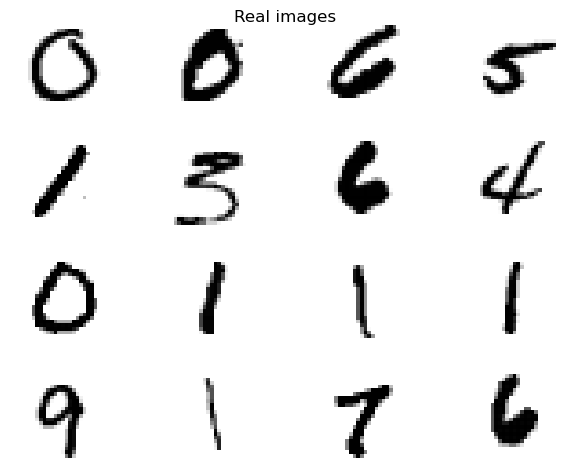

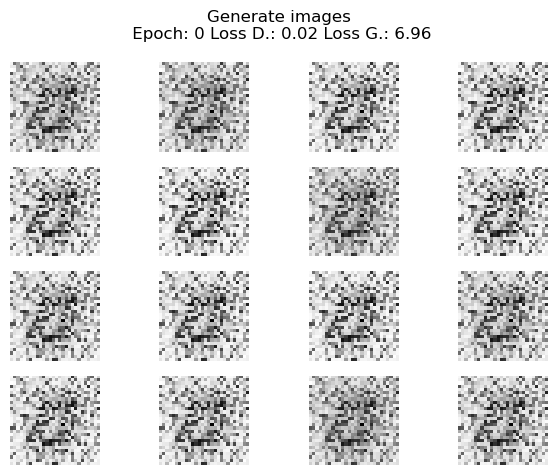

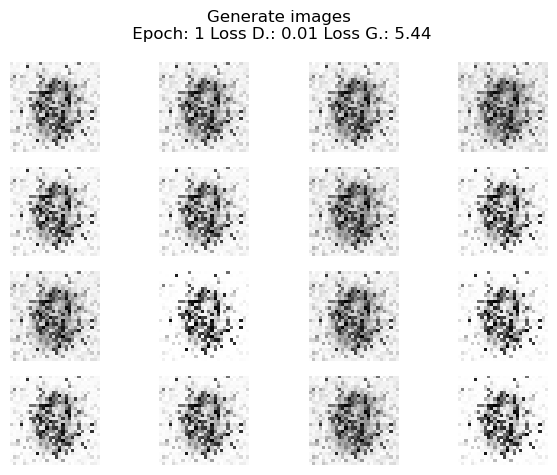

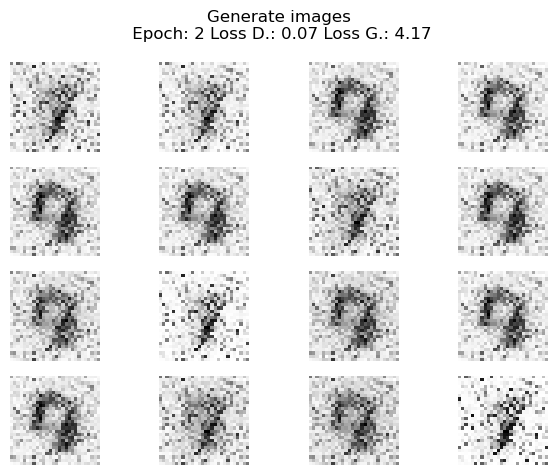

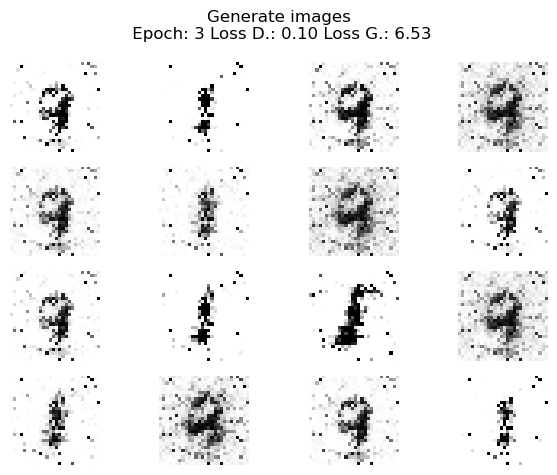

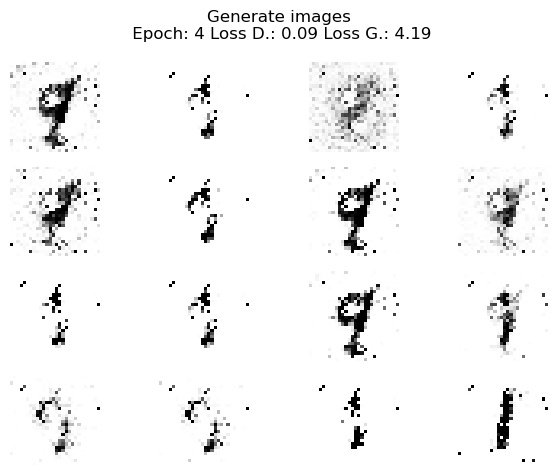

In [4]:
%matplotlib inline

import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time


class Generator(nn.Module):
 

    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 784),
            nn.Tanh(),
        )

    def forward(self, x):
        output = self.model(x)
        output = output.view(x.size(0), 1, 28, 28)
        return output


class Discriminator(nn.Module):
  
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = x.view(x.size(0), 784)
        output = self.model(x)
        return output



def train_gan(batch_size: int = 64, num_epochs: int = 100, device: str = "cuda:0" if torch.cuda.is_available() else "cpu"):
   
    # Add/adjust code.

    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

    try:
        train_set = torchvision.datasets.MNIST(root=".", train=True, download=True, transform=transform)
    except:
        print("Failed to download MNIST, retrying with different URL")
        # see: https://github.com/pytorch/vision/blob/master/torchvision/datasets/mnist.py
        torchvision.datasets.MNIST.resources = [
            ('https://ossci-datasets.s3.amazonaws.com/mnist/train-images-idx3-ubyte.gz',
             'f68b3c2dcbeaaa9fbdd348bbdeb94873'),
            ('https://ossci-datasets.s3.amazonaws.com/mnist/train-labels-idx1-ubyte.gz',
             'd53e105ee54ea40749a09fcbcd1e9432'),
            ('https://ossci-datasets.s3.amazonaws.com/mnist/t10k-images-idx3-ubyte.gz',
             '9fb629c4189551a2d022fa330f9573f3'),
            ('https://ossci-datasets.s3.amazonaws.com/mnist/t10k-labels-idx1-ubyte.gz',
             'ec29112dd5afa0611ce80d1b7f02629c')
        ]
        train_set = torchvision.datasets.MNIST(root=".", train=True, download=True, transform=transform)

    train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)

    # example data
    real_samples, mnist_labels = next(iter(train_loader))

    fig = plt.figure()
    for i in range(16):
        sub = fig.add_subplot(4, 4, 1 + i)
        sub.imshow(real_samples[i].reshape(28, 28), cmap="gray_r")
        sub.axis('off')

    fig.tight_layout()
    fig.suptitle("Real images")
    display(fig)

    time.sleep(5)

    # Set up training
    discriminator = Discriminator().to(device)
    generator = Generator().to(device)
    lr = 0.0001
    loss_function = nn.BCELoss()
    optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)
    optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

    # train
    for epoch in range(num_epochs):
        for n, (real_samples, mnist_labels) in enumerate(train_loader):
            
            """
            Structural Bug:
            assuming a fixed batch size, while the DataLoader may return smaller batches.
            """
            # Data for training the discriminator
            current_batch_size = real_samples.size(0)
            real_samples = real_samples.to(device=device)
            real_samples_labels = torch.ones((current_batch_size, 1)).to(device=device)
            latent_space_samples = torch.randn((current_batch_size, 100)).to(device=device)
            generated_samples = generator(latent_space_samples)
            generated_samples_labels = torch.zeros((current_batch_size, 1)).to(device=device)
            all_samples = torch.cat((real_samples, generated_samples))
            all_samples_labels = torch.cat((real_samples_labels, generated_samples_labels))

            # Training the discriminator
            discriminator.zero_grad()
            output_discriminator = discriminator(all_samples)
            loss_discriminator = loss_function(output_discriminator, all_samples_labels)
            loss_discriminator.backward()
            optimizer_discriminator.step()

            # Data for training the generator
            latent_space_samples = torch.randn((current_batch_size, 100)).to(device=device)

            # Training the generator
            generator.zero_grad()
            generated_samples = generator(latent_space_samples)
            output_discriminator_generated = discriminator(generated_samples)
            loss_generator = loss_function(output_discriminator_generated, real_samples_labels)
            loss_generator.backward()
            optimizer_generator.step()

            """
            Cosmetic Bug:
            incorrect iteration condition.
            """

            # Show loss and samples generated
            if n == len(train_loader) - 1:
                name = f"Generate images\n Epoch: {epoch} Loss D.: {loss_discriminator:.2f} Loss G.: {loss_generator:.2f}"
                generated_samples = generated_samples.detach().cpu().numpy()
                fig = plt.figure()
                for i in range(16):
                    sub = fig.add_subplot(4, 4, 1 + i)
                    sub.imshow(generated_samples[i].reshape(28, 28), cmap="gray_r")
                    sub.axis('off')
                fig.suptitle(name)
                fig.tight_layout()
                clear_output(wait=False)
                display(fig)


train_gan(batch_size=32, num_epochs=5)
